# QSO Spectrum: j0453 (q0450m13)  
**Instrument:** VLT/UVES (reduced with UVES_popler v0.72)  
**Redshift:** z = 2.3  
**Wavelength range:** ~3047 – 10430 Å  
**Dispersion:** 2.5 km/s  
**Exposure time:** 15000 s (5 exposures)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.io import fits

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

## 1. Load the FITS file

In [15]:
fits_path = "../data/raw/j0453_2p30_done/j0453_sp_norm.fits"

with fits.open(fits_path) as hdul:
    hdr  = hdul[0].header
    flux = hdul[0].data.copy()          # normalized flux

# ── Reconstruct log-linear wavelength grid ──────────────────────────────────
naxis1  = hdr['NAXIS1']
crpix1  = hdr.get('CRPIX1', 1)          # first pixel index (1-indexed)
crval1  = hdr['CRVAL1']                 # log10(λ) of reference pixel
cdelt1  = hdr['CD1_1']                  # log10 dispersion per pixel

pixels  = np.arange(naxis1)
wave    = 10 ** (crval1 + (pixels - (crpix1 - 1)) * cdelt1)   # wavelength in Å

# Object metadata
z_em    = hdr.get('UP_ZEM')
obj     = hdr.get('OBJECT', 'unknown')
up_disp = hdr.get('UP_DISP')

print(f"Object       : {obj}")
print(f"z_em         : {z_em}")
print(f"dv           : {up_disp} km/s")
print(f"Wavelength   : {wave.min():.1f} – {wave.max():.1f} Å  ({naxis1} pixels)")
print(f"Flux range   : {flux.min():.3f} – {flux.max():.3f}")
print(f"Flux median  : {np.median(flux):.4f}")

Object       : q0450m13
z_em         : 2.3
dv           : 2.5 km/s
Wavelength   : 3047.2 – 10429.8 Å  (147552 pixels)
Flux range   : -10.879 – 16.161
Flux median  : 0.9961


## 2. Full spectrum overview

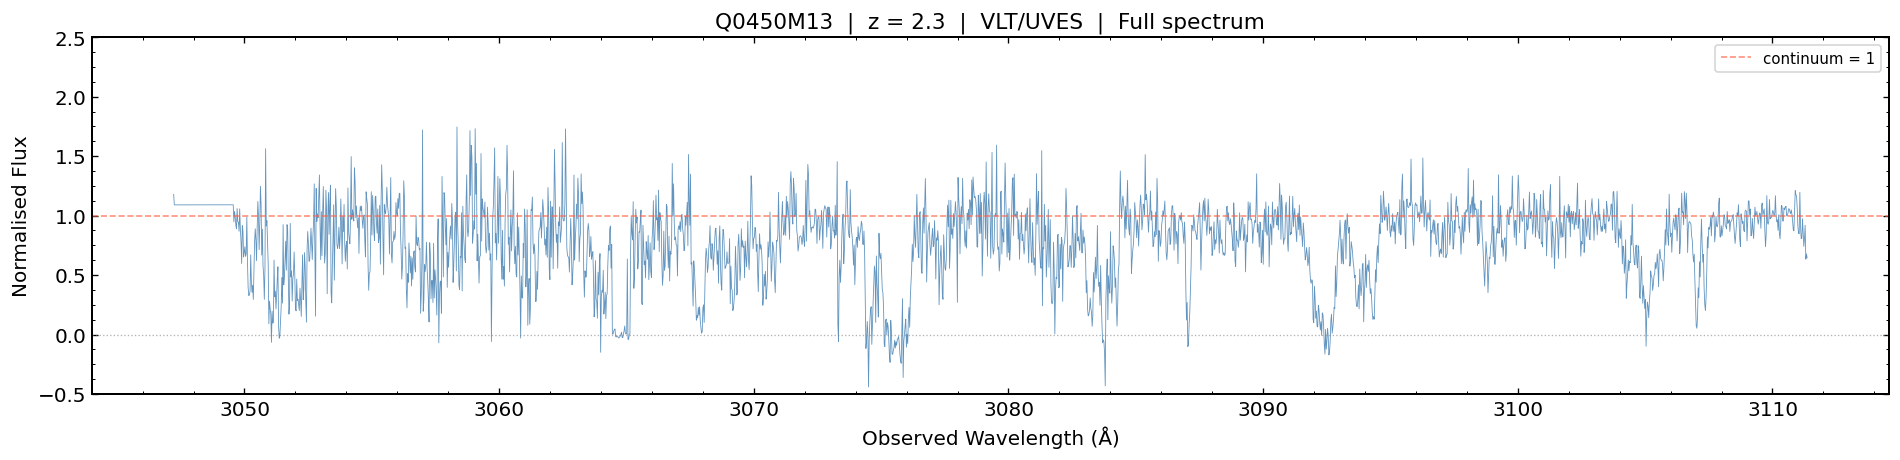

Saved → j0453_full_spectrum.pdf


In [9]:
# Clip extreme pixels for display (keep within [-0.5, 2.5])
flux_plot = np.clip(flux, -0.5, 2.5)

# ── Common QSO absorption/emission lines (rest frame, Å) ────────────────────
lines = {
    r'Ly$\alpha$ 1216': 1216.0,
    'C IV 1549'       : 1549.5,
    'C II 1335'       : 1334.5,
    'Si IV 1397'      : 1397.0,
    'Al II 1671'      : 1670.8,
    'Fe II 2600'      : 2600.2,
    'Mg II 2796'      : 2796.4,
    'Ca II K 3934'    : 3933.7,
}

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(wave[:2499], flux_plot[:2499], color='steelblue', lw=0.5, alpha=0.85, rasterized=True)
ax.axhline(1.0, color='tomato', lw=1.0, ls='--', alpha=0.7, label='continuum = 1')
ax.axhline(0.0, color='gray',   lw=0.8, ls=':',  alpha=0.6)

# Mark lines at the emission redshift
ymin_t, ymax_t = 1.95, 2.35
colors = plt.cm.tab10(np.linspace(0, 0.9, len(lines)))
# for (name, lam_rest), c in zip(lines.items(), colors):
#     lam_obs = lam_rest * (1 + z_em)
#     if wave.min() < lam_obs < wave.max():
#         ax.axvline(lam_obs, color=c, lw=1.2, alpha=0.75, ls='--')
#         ax.text(lam_obs, ymax_t, name, color=c, fontsize=7,
#                 ha='center', va='bottom', rotation=90)

# ax.set_xlim(wave.min(), wave.max())
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel('Observed Wavelength (Å)', fontsize=12)
ax.set_ylabel('Normalised Flux', fontsize=12)
ax.set_title(f'{obj.upper()}  |  z = {z_em}  |  VLT/UVES  |  Full spectrum', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

plt.tight_layout()
plt.savefig('j0453_full_spectrum.pdf', bbox_inches='tight')
plt.show()
print("Saved → j0453_full_spectrum.pdf")

## 3. Lyman-alpha forest zoom

In [ ]:
# Lyman-alpha forest: from Ly-alpha emission down to the Lyman limit
lya_em  = 1216.0 * (1 + z_em)    # Ly-alpha at the QSO redshift
lyb_em  = 1026.0 * (1 + z_em)    # Ly-beta  (approximate lower bound of forest)

mask = (wave >= lyb_em - 200) & (wave <= lya_em + 200)

fig, ax = plt.subplots(figsize=(14, 3.5))

ax.plot(wave[mask], np.clip(flux[mask], -0.2, 1.6),
        color='steelblue', lw=0.6, alpha=0.9, rasterized=True)
ax.axhline(1.0, color='tomato', lw=1.0, ls='--', alpha=0.7, label='continuum')
ax.axhline(0.0, color='gray',   lw=0.8, ls=':',  alpha=0.6)

# Mark Ly-alpha and Ly-beta emission
for lam, label in [(lya_em, r'Ly$\alpha$ (z=2.3)'), (lyb_em, r'Ly$\beta$ (z=2.3)')]:
    ax.axvline(lam, color='firebrick', lw=1.4, ls='-', alpha=0.8)
    ax.text(lam, 1.55, label, color='firebrick', fontsize=8,
            ha='center', va='bottom', rotation=90)

ax.set_xlim(lyb_em - 200, lya_em + 200)
ax.set_ylim(-0.2, 1.7)
ax.set_xlabel('Observed Wavelength (Å)', fontsize=12)
ax.set_ylabel('Normalised Flux', fontsize=12)
ax.set_title(r'Ly$\alpha$ Forest  |  ' + f'{obj.upper()}  (z = {z_em})', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

plt.tight_layout()
plt.savefig('j0453_lya_forest.pdf', bbox_inches='tight')
plt.show()
print("Saved → j0453_lya_forest.pdf")

## 4. Wavelength-band zooms (interactive selector)

Choose any wavelength window to inspect in detail.

In [ ]:
def plot_window(w_min, w_max, flux_min=-0.3, flux_max=1.8, title='', save=None):
    """Plot a wavelength window of the spectrum."""
    mask = (wave >= w_min) & (wave <= w_max)
    if mask.sum() == 0:
        print(f"No pixels in range {w_min}–{w_max} Å")
        return

    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(wave[mask], np.clip(flux[mask], flux_min - 0.1, flux_max + 0.1),
            color='steelblue', lw=0.8, alpha=0.9)
    ax.axhline(1.0, color='tomato', lw=1.0, ls='--', alpha=0.7)
    ax.axhline(0.0, color='gray',   lw=0.8, ls=':',  alpha=0.6)
    ax.set_xlim(w_min, w_max)
    ax.set_ylim(flux_min, flux_max)
    ax.set_xlabel('Observed Wavelength (Å)', fontsize=12)
    ax.set_ylabel('Normalised Flux', fontsize=12)
    ax.set_title(title or f'λ = {w_min}–{w_max} Å', fontsize=13)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches='tight')
        print(f'Saved → {save}')
    plt.show()

# ── Example windows ──────────────────────────────────────────────────────────
# Mg II doublet region
plot_window(9200, 9600, title='Mg II doublet region (z~2.3)')

# C IV region
lam_civ = 1549.5 * (1 + z_em)
plot_window(lam_civ - 300, lam_civ + 300, title=f'C IV 1549 region  (obs. ~{lam_civ:.0f} Å)')

## 5. Flux distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of all flux values
ax = axes[0]
ax.hist(flux, bins=300, range=(-0.5, 2.0), color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(0, color='gray',   ls=':', lw=1)
ax.axvline(1, color='tomato', ls='--', lw=1.2, label='continuum = 1')
ax.set_xlabel('Normalised Flux')
ax.set_ylabel('Number of pixels')
ax.set_title('Flux distribution (full spectrum)')
ax.legend()

# Running median (coarse continuum check)
ax = axes[1]
stride  = 500                               # pixels per bin for running median
n_bins  = len(flux) // stride
w_med   = np.array([wave[i*stride : (i+1)*stride].mean() for i in range(n_bins)])
f_med   = np.array([np.median(flux[i*stride : (i+1)*stride])  for i in range(n_bins)])

ax.plot(w_med, f_med, color='steelblue', lw=1.5)
ax.axhline(1.0, color='tomato', ls='--', lw=1.2, label='continuum = 1')
ax.set_xlabel('Observed Wavelength (Å)')
ax.set_ylabel('Running median flux')
ax.set_title('Running median (500 px bins)')
ax.set_ylim(-0.1, 1.3)
ax.legend()

plt.tight_layout()
plt.savefig('j0453_flux_stats.pdf', bbox_inches='tight')
plt.show()
print("Saved → j0453_flux_stats.pdf")

In [11]:
import numpy as np
from astropy.io import fits

with fits.open("../data/raw/j0453_2p30_done/j0453_sp_norm.fits") as hdul:
    cdelt1 = hdul[0].header["CD1_1"]   # log10 dispersion per pixel

c_kms = 299792.458  # km/s

# Exact (from ratio of adjacent wavelengths)
dv_exact = c_kms * (10**cdelt1 - 1)

# Approximation (valid when CD1_1 is small)
dv_approx = c_kms * np.log(10) * cdelt1

print(f"CD1_1      = {cdelt1:.6e}  (log10 Å/pixel)")
print(f"dv (exact) = {dv_exact:.4f}  km/s/pixel")
print(f"dv (approx)= {dv_approx:.4f}  km/s/pixel")
print(f"Header UP_DISP = {2.5} km/s")   # cross-check from UP_DISP

CD1_1      = 3.621611e-06  (log10 Å/pixel)
dv (exact) = 2.5000  km/s/pixel
dv (approx)= 2.5000  km/s/pixel
Header UP_DISP = 2.5 km/s
